# Analiza widma energii fragmentów rozpadu
Analiza widma, identyfikacja linii widmowych.

In [174]:
# Prosta (y = ax + b) - wartości parametrów otrzymane z kalibracji energetycznej rozpadu, a = 0.02173 MeV, b = 0.43244 MeV
a = 0.021726988040488823
ua = 3.554782238880299e-05
b = 0.4324378442054059
ub = 0.10788787238062508

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [176]:
def load_lst(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Znajdź linię, po której zaczynają się dane (pod $DATA:)
    start_idx = 0
    for i, line in enumerate(lines):
        if '$DATA:' in line:
            start_idx = i + 2  # Dane zaczynają się dwie linie niżej
            break
            
    # Wczytaj dane (kanał i liczba zliczeń)
    # Dane są rozdzielone spacjami
    data = pd.read_csv(filename, skiprows=start_idx, sep=r'\s+', 
                       header=None, names=['channel', 'counts'], nrows=8192)
    return data

### Znalezienie pików alpha

In [177]:
filename = 'dane/pomiar_glowny_rozpadu.lst'
df = load_lst(filename)
    
# 2. Kalibracja energetyczna: E = a * x + b
df['energy'] = df['channel'] * a + b

# 3. Znajdowanie pików
# height=10: ignorujemy szum tła poniżej 10 zliczeń
# prominence=5: pik musi wyróżniać się z otoczenia o co najmniej 5 zliczeń
peaks_indices, _ = find_peaks(df['counts'], height=4, prominence=5, width=2)

# Przygotowanie danych pików
peak_energies = df.loc[peaks_indices, 'energy']
peak_counts = df.loc[peaks_indices, 'counts']
peak_channels = df.loc[peaks_indices, 'channel']

# 4. Wypisanie listy pików
print(f"\n{'='*55}")
print(f"E = {a}*ch + {b}")
print(f"{'='*55}")
print(f"{'Nr':<4} | {'Kanał':<8} | {'Energia [MeV]':<15} | {'Zliczenia':<10}")
print(f"{'-'*55}")

for i, (ch, en, cnt) in enumerate(zip(peak_channels, peak_energies, peak_counts)):
    print(f"{i+1:<4} | {int(ch):<8} | {en:<15.4f} | {int(cnt):<10}")
print(f"{'='*55}\n")


E = 0.021726988040488823*ch + 0.4324378442054059
Nr   | Kanał    | Energia [MeV]   | Zliczenia 
-------------------------------------------------------
1    | 94       | 2.4748          | 1444      
2    | 97       | 2.5400          | 1410      
3    | 110      | 2.8224          | 1527      
4    | 114      | 2.9093          | 1500      
5    | 138      | 3.4308          | 1233      
6    | 154      | 3.7784          | 1122      
7    | 169      | 4.1043          | 1159      
8    | 180      | 4.3433          | 1138      
9    | 189      | 4.5388          | 2024      
10   | 198      | 4.7344          | 14585     
11   | 214      | 5.0820          | 529912    
12   | 231      | 5.4514          | 37913     
13   | 246      | 5.7773          | 10593     
14   | 269      | 6.2770          | 203       
15   | 297      | 6.8854          | 128       
16   | 305      | 7.0592          | 132       
17   | 310      | 7.1678          | 69        
18   | 331      | 7.6241          | 113       
1

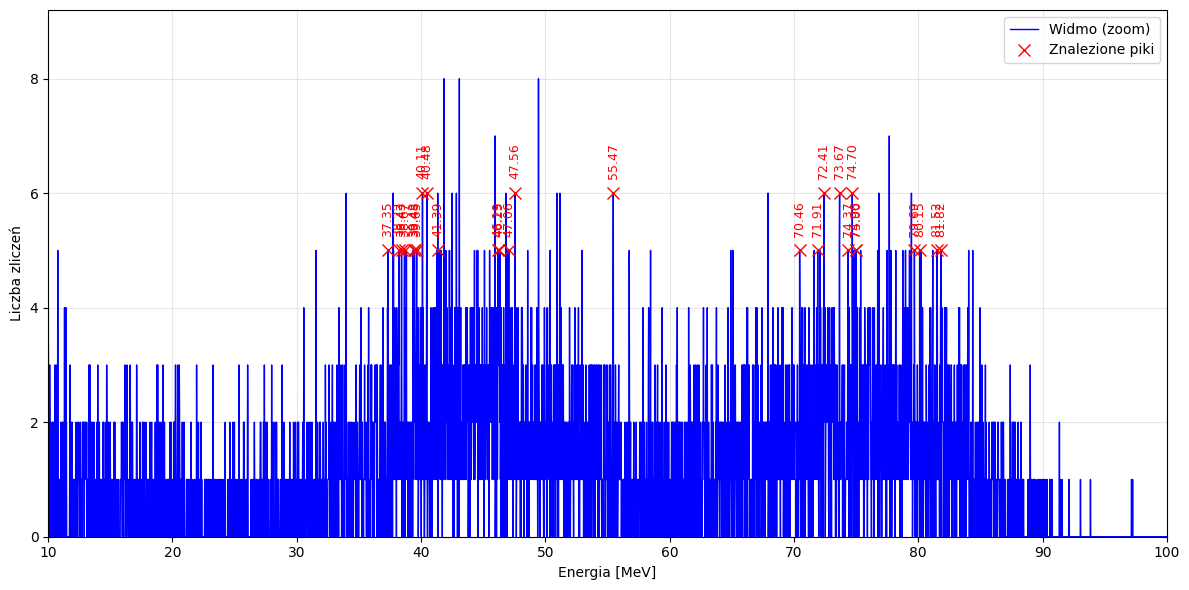

In [178]:
min_energy = 10  # MeV
max_energy = 100  # MeV

# --- 1. PRZYGOTOWANIE DANYCH WYKRESU ---
# Maska dla widma ciągłego (niebieska linia)
mask_spectrum = (df['energy'] >= min_energy) & (df['energy'] <= max_energy)
x_view = df.loc[mask_spectrum, 'energy']
y_view = df.loc[mask_spectrum, 'counts']

# --- 2. NAPRAWA BŁĘDU (KEYERROR) I FILTROWANIE PIKÓW ---
# Konwertujemy piki na tablice NumPy - to eliminuje problemy z indeksami Pandas
peaks_en_arr = np.array(peak_energies)
peaks_cnt_arr = np.array(peak_counts)

# Tworzymy maskę dla pików (tak samo jak dla widma)
mask_peaks = (peaks_en_arr >= min_energy) & (peaks_en_arr <= max_energy)

# Wybieramy tylko pasujące piki
visible_energies = peaks_en_arr[mask_peaks]
visible_counts = peaks_cnt_arr[mask_peaks]

# --- 3. SKALOWANIE OSI Y ---
# Obliczamy max tylko dla widocznego zakresu
if len(y_view) > 0:
    local_max = y_view.max()
else:
    local_max = 10  # Wartość domyślna, gdyby zakres był pusty

plt.figure(figsize=(12, 6))

# Rysowanie widma (zoom)
plt.plot(x_view, y_view, label='Widmo (zoom)', color='blue', linewidth=1)

# Rysowanie przefiltrowanych pików
plt.plot(visible_energies, visible_counts, "rx", label='Znalezione piki', markersize=8)

# Podpisywanie pików
for en, cnt in zip(visible_energies, visible_counts):
    plt.annotate(f"{en:.2f}", 
                 xy=(en, cnt), 
                 xytext=(0, 10), 
                 textcoords='offset points', 
                 ha='center', va='bottom', 
                 fontsize=9, rotation=90, color='red')

plt.xlabel("Energia [MeV]")
plt.ylabel("Liczba zliczeń")
plt.grid(True, alpha=0.3)

# Ustawiamy zakres X i dopasowany zakres Y
plt.xlim(min_energy, max_energy)
plt.ylim(0, local_max * 1.15)  # +15% marginesu u góry na podpisy

plt.legend()
plt.tight_layout()
plt.show()

C:\Users\filip\AppData\Local\Temp\ipykernel_16920\3132341489.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, local_max * 3)  # +15% marginesu u góry na podpisy


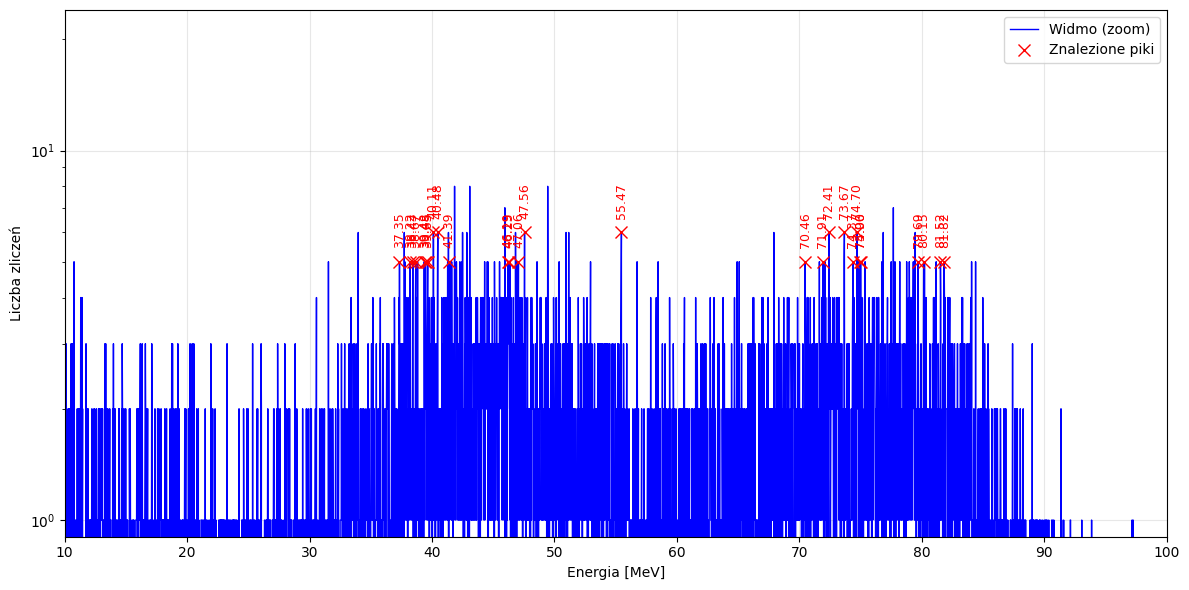

In [179]:
plt.figure(figsize=(12, 6))

# Rysowanie widma (zoom)
plt.plot(x_view, y_view, label='Widmo (zoom)', color='blue', linewidth=1)

# Rysowanie przefiltrowanych pików
plt.plot(visible_energies, visible_counts, "rx", label='Znalezione piki', markersize=8)

# Podpisywanie pików
for en, cnt in zip(visible_energies, visible_counts):
    plt.annotate(f"{en:.2f}", 
                 xy=(en, cnt), 
                 xytext=(0, 10), 
                 textcoords='offset points', 
                 ha='center', va='bottom', 
                 fontsize=9, rotation=90, color='red')

plt.yscale('log')

plt.xlabel("Energia [MeV]")
plt.ylabel("Liczba zliczeń")
plt.grid(True, alpha=0.3)

# Ustawiamy zakres X i dopasowany zakres Y
plt.xlim(min_energy, max_energy)
plt.ylim(0, local_max * 3)  # +15% marginesu u góry na podpisy

plt.legend()
plt.tight_layout()
plt.show()

In [180]:
# 1. Baza danych energii alfa (Główne linie w MeV)
# Źródło: NNDC (National Nuclear Data Center)
# Uwaga: Podaję główne linie (największe prawdopodobieństwo)
known_isotopes = {
    # --- SZEREG URANOWY (4n+2) - TŁO ---
    # U-238 dominuje w masie (89%), ale ma niską aktywność właściwą.
    'U-238':  [4.198, 4.151],      
    'U-234':  [4.774, 4.722],      # Ważne: Wzbogacenie uranu (do 10% U-235) często sztucznie podbija też U-234!
    'Th-230': [4.687, 4.620],      
    'Ra-226': [4.784, 4.601],      
    'Rn-222': [5.489],             
    'Po-218': [6.002],             
    'Po-214': [7.687],             
    'Po-210': [5.304],             

    # --- SZEREG AKTYNOWY (4n+3) ---
    # U-235 (10%) - znaczny sygnał w tej próbce.
    'U-235':  [4.398, 4.365, 4.59, 4.21], 
    'Pa-231': [5.013, 5.029, 4.95],       
    'Th-227': [6.038, 5.978, 5.757],      
    'Ra-223': [5.716, 5.607, 5.75],       
    'Rn-219': [6.819, 6.55],              
    'Bi-211': [6.623, 6.278],             
    'Po-215': [7.386],                    

    # --- PRODUKTY AKTYWACJI NEUTRONOWEJ (Kluczowe zmiany) ---
    
    # U-236: Produkt wychwytu neutronu przez U-235.
    # W uranie naturalnym nieobecny, tu OBOWIĄZKOWY.
    # Linie alfa leżą blisko U-235, mogą poszerzać jego pik.
    'U-236': [4.494, 4.445],

    # Pu-239: Produkt wychwytu neutronu przez U-238.
    # Główny składnik plutonu "grade". 
    'Pu-239': [5.156, 5.144, 5.105],

    # Pu-240: Jeśli strumień neutronów był wysoki, Pu-239 łapie kolejny neutron.
    # W spektrometrii alfa Pu-239 i Pu-240 są zwykle nierozróżnialne (tworzą jeden pik),
    # ale warto mieć świadomość tych linii.
    'Pu-240': [5.168, 5.124],

    # Np-237: Z rozpadu U-237 (który powstaje z U-236 + n).
    # Często spotykany w wypalonym paliwie.
    'Np-237': [4.788, 4.766], # Uwaga: Nakłada się na U-234!

    # Am-241: Jeśli próbka "leżakowała" po naświetlaniu.
    # Powstaje z rozpadu beta Pu-241. Silny emiter.
    # Często używany do kalibracji, ale tu może być produktem.
    'Am-241': [5.486, 5.443], # Uwaga: Bardzo blisko Rn-222 (5.489)!

    # Uzupełnienie linii Pa-231 (ważne po aktywacji Th-230)
    'Pa-231': [5.013, 5.029, 4.95, 5.058], 

    # Produkty zaawansowanej aktywacji (Transuranowce)
    # Cm-243 pasuje idealnie do 5.778
    'Cm-243': [5.785, 5.741], 
    
    # Cm-244 często występuje razem z Cm-243
    'Cm-244': [5.805, 5.763],
}

# Twoje znalezione piki (przykład z poprzedniego kontekstu)
# peak_energies = [...] 

# 2. Funkcja do identyfikacji
def identify_peaks(found_energies, library, tolerance=0.05):
    """
    found_energies: lista znalezionych energii pików
    library: słownik znanych izotopów
    tolerance: +/- MeV (np. 0.05 MeV = 50 keV)
    """
    print(f"{'Znaleziony Pik':<15} | {'Pasujący Izotop':<15} | {'Energia Ref.':<15} | {'Różnica':<10}")
    print("-" * 65)
    
    for peak in found_energies:
        match_found = False
        for isotope, lines in library.items():
            for ref_energy in lines:
                if abs(peak - ref_energy) <= tolerance:
                    diff = peak - ref_energy
                    print(f"{peak:<15.4f} | {isotope:<15} | {ref_energy:<15.3f} | {diff:+.4f}")
                    match_found = True
        
        if not match_found:
            print(f"{peak:<15.4f} | {'???':<15} | {'-':<15} | {'-'}")

# Uruchomienie sprawdzenia (przyjęto tolerancję 50 keV)
identify_peaks(peak_energies, known_isotopes, tolerance=0.05)

Znaleziony Pik  | Pasujący Izotop | Energia Ref.    | Różnica   
-----------------------------------------------------------------
2.4748          | ???             | -               | -
2.5400          | ???             | -               | -
2.8224          | ???             | -               | -
2.9093          | ???             | -               | -
3.4308          | ???             | -               | -
3.7784          | ???             | -               | -
4.1043          | U-238           | 4.151           | -0.0467
4.3433          | U-235           | 4.365           | -0.0217
4.5388          | U-236           | 4.494           | +0.0448
4.7344          | U-234           | 4.774           | -0.0396
4.7344          | U-234           | 4.722           | +0.0124
4.7344          | Th-230          | 4.687           | +0.0474
4.7344          | Ra-226          | 4.784           | -0.0496
4.7344          | Np-237          | 4.766           | -0.0316
5.0820          | Pa-231          | 5

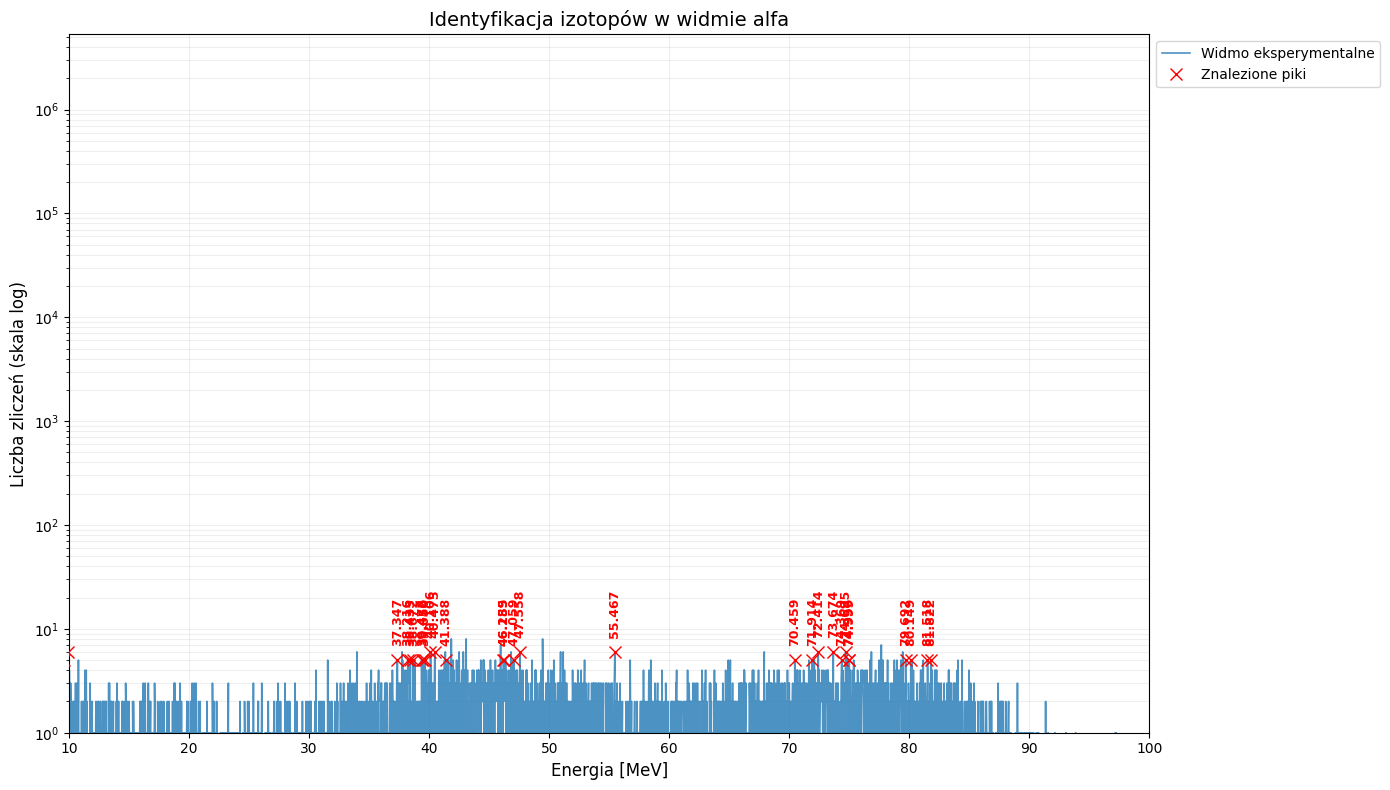

In [181]:
import matplotlib.pyplot as plt
import numpy as np  # Upewniamy się, że numpy jest zaimportowany

# --- A. Konfiguracja wykresu ---
plt.figure(figsize=(14, 8))

# Rysowanie widma
plt.plot(df['energy'], df['counts'], label='Widmo eksperymentalne', 
         color='#1f77b4', linewidth=1.2, alpha=0.8)

# --- B. NAPRAWA BŁĘDU TYPÓW (KeyError) ---
# Konwertujemy dane pików na czyste tablice NumPy, aby indeksy szły od 0 do N
peak_energies_arr = np.array(peak_energies)
peak_counts_arr = np.array(peak_counts)

# --- C. Filtrowanie i rysowanie pików ---
# Teraz operujemy na tablicach _arr, które nie mają problemów z indeksami
valid_peaks_indices = [i for i, en in enumerate(peak_energies_arr) if en > 1.0]
valid_energies = peak_energies_arr[valid_peaks_indices]
valid_counts = peak_counts_arr[valid_peaks_indices]

plt.plot(valid_energies, valid_counts, "rx", label='Znalezione piki', markersize=8, zorder=5)

# --- D. Ustawienie limitów OSI ---
plt.xlim(min_energy, max_energy) 
plt.yscale('log')
y_max_limit = df['counts'].max() * 10 
plt.ylim(bottom=1, top=y_max_limit)

# --- E. Podpisywanie pików ---
for en, cnt in zip(valid_energies, valid_counts):
    plt.annotate(f"{en:.3f}", 
                 xy=(en, cnt), 
                 xytext=(0, 10), 
                 textcoords='offset points', 
                 ha='center', va='bottom', 
                 fontsize=9, rotation=90, color='red', weight='bold')

# --- F. Rysowanie linii teoretycznych ---
# (Tutaj wklejam Twój słownik i logikę z poprzedniego kroku)
iso_colors = {

}

used_labels = set()
for iso, lines in known_isotopes.items():
    color = iso_colors.get(iso, 'gray')
    for ref_energy in lines:
        if min_energy <= ref_energy <= max_energy:
            plt.axvline(x=ref_energy, color=color, linestyle='--', alpha=0.5, linewidth=1)
            plt.text(ref_energy, y_max_limit * 0.95, f" {iso}", 
                     color=color, rotation=90, ha='right', va='top', fontsize=8, weight='bold')
            if iso not in used_labels:
                plt.plot([], [], color=color, linestyle='--', label=f'{iso}')
                used_labels.add(iso)

# --- G. Kosmetyka końcowa ---
plt.xlabel("Energia [MeV]", fontsize=12)
plt.ylabel("Liczba zliczeń (skala log)", fontsize=12)
plt.title("Identyfikacja izotopów w widmie alfa", fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

plt.show()

In [182]:
def rebin_data(x, y, bin_size):
    """
    Funkcja łącząca dane w 'wiaderka'.
    x: energia/kanały
    y: zliczenia
    bin_size: ile kanałów wrzucamy do jednego wiaderka (np. 5 lub 10)
    """
    # Obcinamy końcówkę, żeby długość tablicy była podzielna przez bin_size
    n_points = len(x) - (len(x) % bin_size)
    x_trimmed = x[:n_points]
    y_trimmed = y[:n_points]
    
    # Przekształcamy tablicę do macierzy (wiersze = ilość nowych punktów, kolumny = bin_size)
    # Nowy X to średnia z wiaderka, Nowy Y to suma zliczeń w wiaderku
    x_rebinned = x_trimmed.reshape(-1, bin_size).mean(axis=1)
    y_rebinned = y_trimmed.reshape(-1, bin_size).sum(axis=1)
    
    # Niepewność statystyczna (Poisson): pierwiastek z liczby zliczeń
    y_err = np.sqrt(y_rebinned)
    
    # Zabezpieczenie przed zerową niepewnością (tam gdzie 0 zliczeń, dajemy wagę 1)
    y_err[y_err == 0] = 1.0
    
    return x_rebinned, y_rebinned, y_err

def gaussian(x, amp, mu, sigma):
    """Pojedynczy Gauss"""
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def double_gaussian(x, a1, m1, s1, a2, m2, s2):
    """Suma dwóch Gaussów"""
    return gaussian(x, a1, m1, s1) + gaussian(x, a2, m2, s2)

Rozpoczynam dopasowanie...
Fit OK.
------------------------------------------------------------
WYNIKI DOPASOWANIA:
Pik 1 (Lekki): Centrum = 2046.30 +/- 11.92 kanałów
               Pole    ≈ 2282 zliczeń (57.0%)
Pik 2 (Ciężki): Centrum = 3438.21 +/- 11.12 kanałów
               Pole    ≈ 1721 zliczeń (43.0%)
Suma pól ≈ 4003 zliczeń
Stosunek pól (Lekki / Ciężki) = 1.3260
------------------------------------------------------------
Pełne parametry (wartość +/- niepewność):
Amplituda 1: 21.31 +/- 0.63
Pozycja 1:   2046.30 +/- 11.92
Szerokość 1: 427.24 +/- 12.78
------------------------------
Amplituda 2: 21.35 +/- 0.67
Pozycja 2:   3438.21 +/- 11.12
Szerokość 2: 321.59 +/- 8.86
------------------------------------------------------------


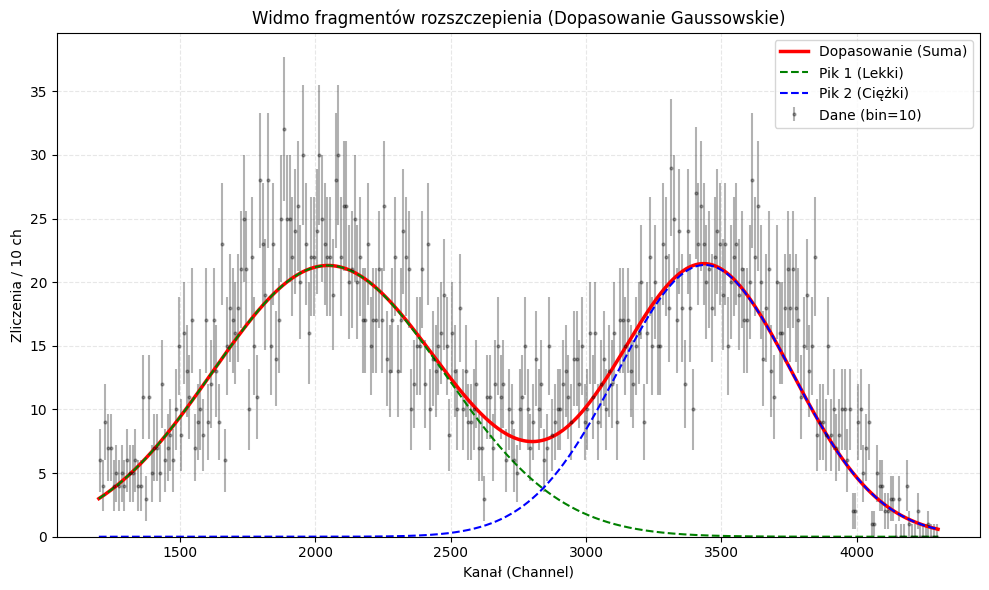

In [188]:
BIN_SIZE = 10   # Agregacja danych

# A. USTAWIENIA WIDOKU (To rozwiązuje problem ze skalą)
VIEW_MIN = 1200
VIEW_MAX = 4300  # Maksymalny kanał (całe widmo)

# B. USTAWIENIA DOPASOWANIA (FIT)
# Zakres w KANAŁACH
FIT_MIN = 1200  
FIT_MAX = 4300

# --- 4. PRZETWARZANIE ---

# Rebinning
x_binned, y_binned, y_err = rebin_data(raw_x, raw_y, BIN_SIZE)

# Maska do WIZUALIZACJI (tylko dane powyżej odcięcia)
view_mask = (x_binned >= VIEW_MIN) & (x_binned <= VIEW_MAX)
x_view = x_binned[view_mask]
y_view = y_binned[view_mask]
y_err_view = y_err[view_mask]

# Maska do FITOWANIA (tylko zakres zainteresowania)
fit_mask = (x_binned >= FIT_MIN) & (x_binned <= FIT_MAX)
x_fit = x_binned[fit_mask]
y_fit = y_binned[fit_mask]
y_err_fit = y_err[fit_mask]

# --- 5. DOPASOWANIE (FIT) ---

# Zgadywanie parametrów (p0)
guess_amp = max(y_fit) if len(y_fit) > 0 else 10
guess_center1 = (FIT_MIN + FIT_MAX) * 0.4  # Zgaduję: w 40% zakresu
guess_center2 = (FIT_MIN + FIT_MAX) * 0.7  # Zgaduję: w 70% zakresu
guess_width = (FIT_MAX - FIT_MIN) / 10     # Startowa szerokość

p0_guess = [guess_amp, guess_center1, guess_width, 
            guess_amp/2, guess_center2, guess_width]

fit_successful = False
popt = []
perr = []

print("Rozpoczynam dopasowanie...")

try:
    if len(x_fit) > 10: # Sprawdzenie czy mamy dane
        # --- KLUCZOWE: Obliczenie fitu i macierzy kowariancji ---
        popt, pcov = curve_fit(double_gaussian, x_fit, y_fit, p0=p0_guess, sigma=y_err_fit, absolute_sigma=True)
        
        # Obliczenie niepewności parametrów (pierwiastek z przekątnej macierzy kowariancji)
        perr = np.sqrt(np.diag(pcov))
        
        fit_successful = True
        print(f"Fit OK.")
    else:
        print("Za mało punktów w zakresie fitowania!")
except RuntimeError:
    print("Nie udało się dopasować funkcji (RuntimeError). Spróbuj zmienić parametry startowe p0.")
except Exception as e:
    print(f"Wystąpił inny błąd: {e}")

if fit_successful:
    a1, m1, s1, a2, m2, s2 = popt
    da1, dm1, ds1, da2, dm2, ds2 = perr # Niepewności
    
    # Pole = Amplituda * Sigma * sqrt(2*pi)
    # Dzielimy przez BIN_SIZE, aby uzyskać przybliżoną liczbę zliczeń
    area1 = (a1 * np.abs(s1) * np.sqrt(2 * np.pi)) / BIN_SIZE
    area2 = (a2 * np.abs(s2) * np.sqrt(2 * np.pi)) / BIN_SIZE
    
    total_area = area1 + area2
    ratio = area1 / area2 if area2 > 0 else 0

    print("-" * 60)
    print(f"WYNIKI DOPASOWANIA:")
    print(f"Pik 1 (Lekki): Centrum = {m1:.2f} +/- {dm1:.2f} kanałów")
    print(f"               Pole    ≈ {area1:.0f} zliczeń ({area1/total_area:.1%})")
    print(f"Pik 2 (Ciężki): Centrum = {m2:.2f} +/- {dm2:.2f} kanałów")
    print(f"               Pole    ≈ {area2:.0f} zliczeń ({area2/total_area:.1%})")
    print(f"Suma pól ≈ {total_area:.0f} zliczeń")
    print(f"Stosunek pól (Lekki / Ciężki) = {ratio:.4f}")
    print("-" * 60)
    print(f"Pełne parametry (wartość +/- niepewność):")
    print(f"Amplituda 1: {a1:.2f} +/- {da1:.2f}")
    print(f"Pozycja 1:   {m1:.2f} +/- {dm1:.2f}")
    print(f"Szerokość 1: {s1:.2f} +/- {ds1:.2f}")
    print("-" * 30)
    print(f"Amplituda 2: {a2:.2f} +/- {da2:.2f}")
    print(f"Pozycja 2:   {m2:.2f} +/- {dm2:.2f}")
    print(f"Szerokość 2: {s2:.2f} +/- {ds2:.2f}")
    print("-" * 60)

# --- 6. WIZUALIZACJA ---

plt.figure(figsize=(10, 6))

# Rysujemy TYLKO dane z 'view_mask'
plt.errorbar(x_view, y_view, yerr=y_err_view, fmt='.', c='black', alpha=0.3, label=f'Dane (bin={BIN_SIZE})', markersize=4)

if fit_successful:
    # Rysujemy fit w zakresie fitowania
    x_smooth = np.linspace(FIT_MIN, FIT_MAX, 1000)
    
    # Suma
    plt.plot(x_smooth, double_gaussian(x_smooth, *popt), 'r-', lw=2.5, label='Dopasowanie (Suma)')
    
    # Składowe
    plt.plot(x_smooth, gaussian(x_smooth, *popt[:3]), 'g--', lw=1.5, label='Pik 1 (Lekki)')
    plt.plot(x_smooth, gaussian(x_smooth, *popt[3:]), 'b--', lw=1.5, label='Pik 2 (Ciężki)')

plt.xlabel("Kanał (Channel)")
plt.ylabel(f"Zliczenia / {BIN_SIZE} ch")
plt.title("Widmo fragmentów rozszczepienia (Dopasowanie Gaussowskie)")
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')

# Automatyczne skalowanie Y do widocznych danych
plt.autoscale(enable=True, axis='y') 

# Opcjonalne wymuszenie od zera, jeśli autoscale utnie dół
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

### Wyznaczenie energii fragmentów

In [187]:

e1 = a * m1 + b
e2 = a * m2 + b

# Pełna propagacja błędu dla energii
# m1, m2 to wartości kanałów (np. 1500), dm1, dm2 to niepewności z curve_fit
de1 = np.sqrt( (a * dm1)**2 + (m1 * ua)**2 + ub**2 )
de2 = np.sqrt( (a * dm2)**2 + (m2 * ua)**2 + ub**2 )

print(f"Piki Energii:")
print(f"E1 (Ciężki fr.): {e1:.2f} +/- {de1:.2f} MeV")
print(f"E2 (Lekki fr.):  {e2:.2f} +/- {de2:.2f} MeV")

# 2. Obliczanie Mas
# Z fizyki: Lżejszy fragment ma WIĘKSZĄ energię kinetyczną.
# Zatem e2 (wyższa energia) odpowiada Ml, a e1 (niższa) odpowiada Mh.

A = 233.6

# Wzór na masę LEKKIEGO fragmentu (Ml):
# Ml = A * (Energia_Ciężkiego) / (Suma_Energii)
# Energia_Ciężkiego to e1 (ten z niższą energią)
M2 = A * e1 / (e1 + e2)

# Wzór na masę CIĘŻKIEGO fragmentu (Mh):
M1 = A * e2 / (e1 + e2)
# Lub prościej: Mh = A - Ml

# 3. Obliczanie niepewności Mas (Poprawiony wzór "na krzyż")
# Zmienna mianownik jest wspólna
denominator = (e1 + e2)**2

dM1 = (A / denominator) * np.sqrt( (e2 * de1)**2 + (e1 * de2)**2 )

# Niepewność masy ciężkiej jest taka sama (bo suma mas jest stała)
dM2 = dM1

R = M2 / M1 # Stosunek mas (Ciężki / Lekki)

print("-" * 40)
print(f"WYNIKI KOŃCOWE:")
print(f"Masa fragmentu M1 = {M1:.2f} +/- {dM1:.2f} u")
print(f"Masa fragmentu M2 = {M2:.2f} +/- {dM2:.2f} u")
print(f"Stosunek mas R = {R:.3f}")
print("-" * 40)

Piki Energii:
E1 (Ciężki fr.): 44.89 +/- 0.29 MeV
E2 (Lekki fr.):  75.13 +/- 0.29 MeV
----------------------------------------
WYNIKI KOŃCOWE:
Masa fragmentu M1 = 146.23 +/- 0.41 u
Masa fragmentu M2 = 87.37 +/- 0.41 u
Stosunek mas R = 0.597
----------------------------------------
